<a href="https://colab.research.google.com/github/pyrenaaaaaa/Emotion-Aware-Companion/blob/text/Ravdess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


# Install Dependencies

In [2]:
!pip install librosa
!pip install resampy
# Restart kernel after installing
import IPython
IPython.display.clear_output()

# Imports

In [3]:
import librosa
from librosa import display
import numpy as np
import os
import pandas as pd
import glob
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import keras
from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding, LSTM, Dropout, Activation, Conv1D, MaxPooling1D, Flatten
from keras.optimizers import RMSprop
from keras.callbacks import ModelCheckpoint

# Load Audio File (Sample)

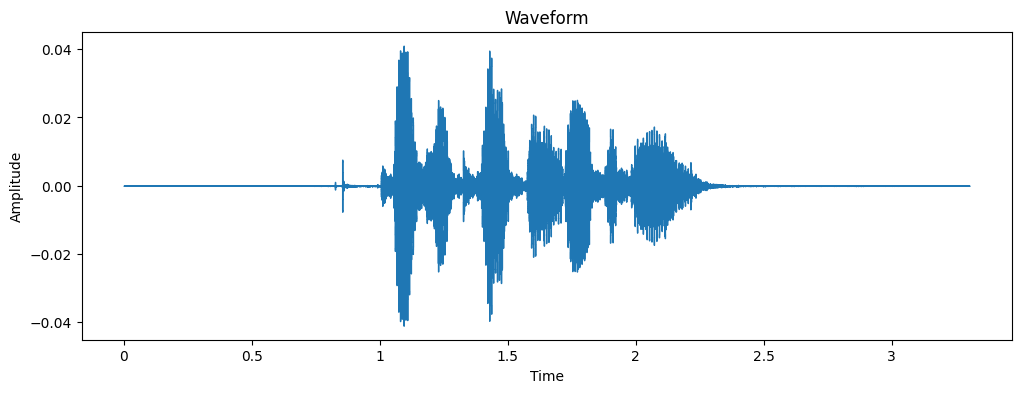

In [4]:
data, sampling_rate = librosa.load('/content/drive/MyDrive/EmotionCompanion/datasets/voice/Ravdess/Actor_01/03-01-01-01-01-01-01.wav')

plt.figure(figsize=(12, 4))
librosa.display.waveshow(data, sr=sampling_rate)
plt.title("Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

# Load All files & Extract Features (MFCCs)

In [5]:
!pip install resampy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 82.5 MB/s eta 0:00:00


In [ ]:
path = '/content/drive/My Drive/EmotionCompanion/datasets/voice/Ravdess'
lst = []

for subdir, dirs, files in os.walk(path):
    for file in files:
        # Only process files that end with '.wav'
        if not file.lower().endswith('.wav'):
            continue
        try:
            # Load audio file
            X, sample_rate = librosa.load(os.path.join(subdir, file), res_type='kaiser_fast')

            # Extract MFCC features
            mfccs = np.mean(librosa.feature.mfcc(y=X, sr=sample_rate, n_mfcc=40).T, axis=0)

            # Extract emotion label from filename (assuming label is in a fixed position)
            label = file[6:8]  # Extract the emotion code
            lst.append((mfccs, label))

        except Exception as e:
            print(f"Error processing {file}: {e}")
            continue

# Convert to NumPy arrays
# X, y = zip(*lst)
# X = np.asarray(X)
# y = np.asarray(y)

# print("Data Shape:", X.shape, y.shape)

# Convert list to NumPy arrays
X, y = zip(*lst)
X = np.asarray(X, dtype=np.float32)  # Fix: Ensure features are float
y = np.asarray(y, dtype=np.int32)  # Fix: Convert labels to integers

print("Data Shape:", X.shape, y.shape)  # Should be (num_samples, 40) and (num_samples,)

In [5]:
print("Data Shape:", X.shape, y.shape)  # Should be (num_samples, 40) and (num_samples,)

Data Shape: (2880, 40) (2880,)


# Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# Shift labels to be zero indexed

In [7]:
# Fix: Shift labels to be zero-indexed (change from 1-8 to 0-7)
y_train -= 1
y_test -= 1

# Check if labels are updated correctly
print("Unique labels in y_train:", np.unique(y_train))
print("Unique labels in y_test:", np.unique(y_test))
print("Min label:", y_train.min(), "Max label:", y_train.max())

# Convert to correct data types (just in case)
X_train_cnn = np.expand_dims(X_train, axis=-1).astype(np.float32)
X_test_cnn = np.expand_dims(X_test, axis=-1).astype(np.float32)
y_train = y_train.astype(np.int32)
y_test = y_test.astype(np.int32)

Unique labels in y_train: [0 1 2 3 4 5 6 7]
Unique labels in y_test: [0 1 2 3 4 5 6 7]
Min label: 0 Max label: 7


# Decision Tree Classifier

In [8]:
dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

predictions = dtree.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.77      0.86      0.81        56
           1       0.76      0.82      0.79       110
           2       0.80      0.80      0.80       128
           3       0.82      0.80      0.81       118
           4       0.84      0.75      0.79       142
           5       0.77      0.75      0.76       126
           6       0.71      0.81      0.75       136
           7       0.82      0.76      0.79       135

    accuracy                           0.79       951
   macro avg       0.79      0.79      0.79       951
weighted avg       0.79      0.79      0.79       951



# Random Forest Classifier

In [9]:
rforest = RandomForestClassifier(criterion="gini", max_depth=10, max_features="log2",
                                 max_leaf_nodes=100, min_samples_leaf=3, min_samples_split=20,
                                 n_estimators=22000, random_state=5)

rforest.fit(X_train, y_train)
predictions = rforest.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.89      0.57      0.70        56
           1       0.61      0.96      0.75       110
           2       0.88      0.83      0.85       128
           3       0.81      0.74      0.77       118
           4       0.93      0.80      0.86       142
           5       0.85      0.83      0.84       126
           6       0.81      0.71      0.76       136
           7       0.79      0.87      0.83       135

    accuracy                           0.80       951
   macro avg       0.82      0.79      0.79       951
weighted avg       0.82      0.80      0.80       951



# Prepare Data for Neural Network

In [10]:
X_train_cnn = np.expand_dims(X_train, axis=2)
X_test_cnn = np.expand_dims(X_test, axis=2)

print(X_train_cnn.shape, X_test_cnn.shape)

(1929, 40, 1) (951, 40, 1)


# Buld CNN Model

In [13]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Conv1D, MaxPooling1D, Flatten, Input
from keras.optimizers import RMSprop

# Define model
model = Sequential()

# Fix: Use Input(shape=...) as first layer
model.add(Input(shape=(40, 1)))  # Explicit input layer

model.add(Conv1D(128, 5, padding='same'))
model.add(Activation('relu'))
model.add(Dropout(0.1))
model.add(MaxPooling1D(pool_size=(8)))

model.add(Conv1D(128, 5, padding='same'))
model.add(Activation('relu'))
model.add(Dropout(0.1))
model.add(Flatten())

model.add(Dense(10))
model.add(Activation('softmax'))

# Fix: Use learning_rate instead of lr, and remove decay
opt = RMSprop(learning_rate=0.00005, rho=0.9, epsilon=1e-07)

# Compile the model
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

# Print summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)                    │ (None, 40, 128)             │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 40, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 40, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 5, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 5, 128)              │          82,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 5, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 5, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 640)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           6,410 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 89,226 (348.54 KB)

 Trainable params: 89,226 (348.54 KB)

 Non-trainable params: 0 (0.00 B)

# Train the Model

In [14]:
cnnhistory = model.fit(X_train_cnn, y_train, batch_size=16, epochs=1000, validation_data=(X_test_cnn, y_test))

Epoch 1/1000
121/121 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.1245 - loss: 8.7042 - val_accuracy: 0.1325 - val_loss: 3.0277
Epoch 2/1000
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1444 - loss: 6.1298 - val_accuracy: 0.1809 - val_loss: 2.5803
Epoch 3/1000
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1605 - loss: 5.2876 - val_accuracy: 0.2629 - val_loss: 2.1654
Epoch 4/1000
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1704 - loss: 4.4880 - val_accuracy: 0.1735 - val_loss: 3.1485
Epoch 5/1000
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1656 - loss: 3.9848 - val_accuracy: 0.2513 - val_loss: 2.0841
Epoch 6/1000
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1845 - loss: 3.3988 - val_accuracy: 0.2135 - val_loss: 2.0595
Epoch 7/1000
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1877 - loss: 2.9071 - val_accuracy: 0.2608 - val_loss: 1.8745
Epoch 8/1000
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2056 - loss: 2.5710 -

# Plot Loss & Accuracy

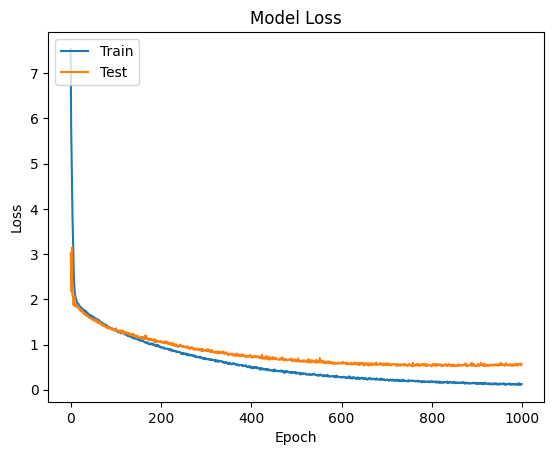

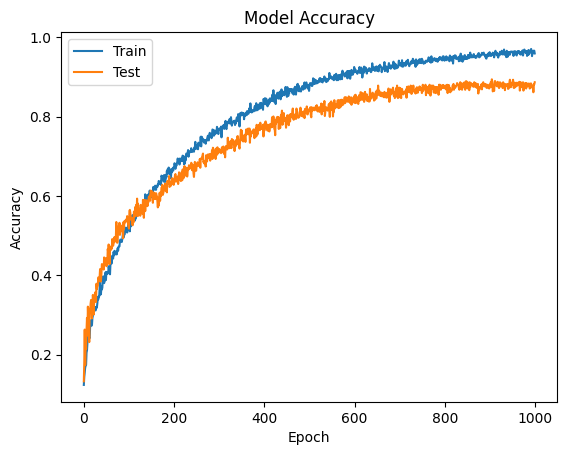

In [15]:
plt.plot(cnnhistory.history['loss'])
plt.plot(cnnhistory.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

plt.plot(cnnhistory.history['accuracy'])
plt.plot(cnnhistory.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Save the Model

Saved trained model at /content/drive/My Drive/EmotionCompanion/models/Ravdess_Model_Final/Emotion_Voice_Detection_Model.h5 


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)                    │ (None, 40, 128)             │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 40, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 40, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 5, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 5, 128)              │          82,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 5, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 5, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 640)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           6,410 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 89,228 (348.55 KB)

 Trainable params: 89,226 (348.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8899 - loss: 0.5717
Test Loss: 0.5638572573661804
Test Accuracy: 0.886435329914093

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
              precision    recall  f1-score   support

           0       0.88      0.77      0.82        56
           1       0.85      0.91      0.88       110
           2       0.89      0.92      0.90       128
           3       0.87      0.92      0.89       118
           4       0.85      0.82      0.83       142
           5       0.93      0.87      0.90       126
           6       0.89      0.88      0.88       136
           7       0.93      0.96      0.94       135

    accuracy                           0.89       951
   macro avg       0.89      0.88      0.88       951
weighted avg       0.89      0.89      0.89       951



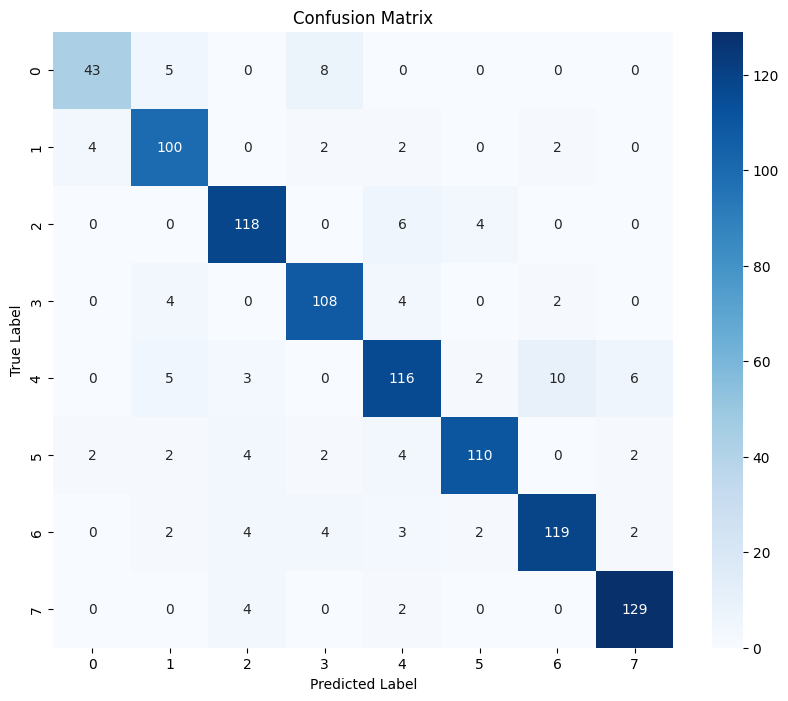

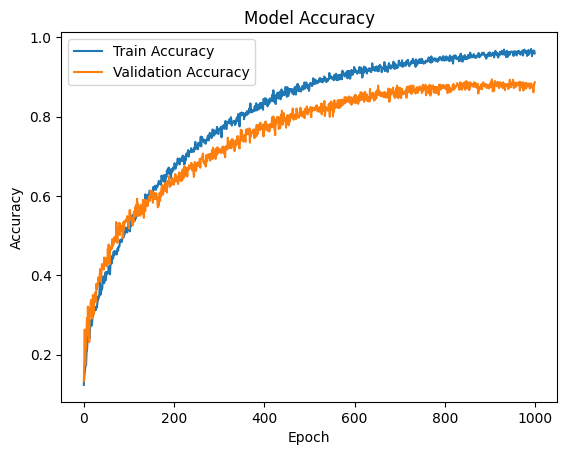

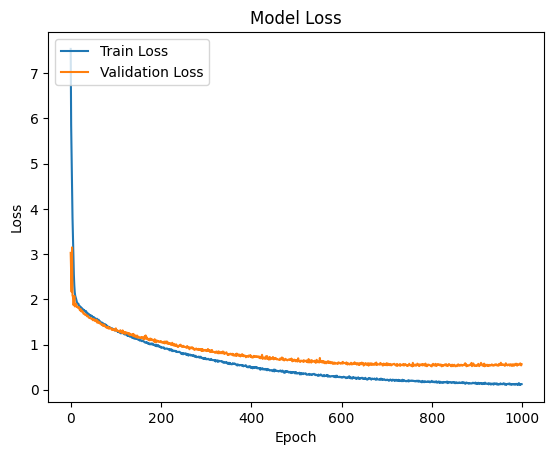

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import keras

# Set model name and save directory
model_name = 'Emotion_Voice_Detection_Model.h5'
save_dir = '/content/drive/My Drive/EmotionCompanion/models/Ravdess_Model_Final'

# Create directory if it doesn't exist
if not os.path.isdir(save_dir):
    os.makedirs(save_dir)

# Save model and weights
model_path = os.path.join(save_dir, model_name)
model.save(model_path)
print('Saved trained model at %s ' % model_path)

# Load the saved model for evaluation
loaded_model = keras.models.load_model(model_path)
loaded_model.summary()

# Evaluate the model on test data
loss, acc = loaded_model.evaluate(X_test_cnn, y_test)
evaluation_text = f"Test Loss: {loss}\nTest Accuracy: {acc}\n"
print(evaluation_text)

# Create evaluation directory within the save_dir
eval_dir = os.path.join(save_dir, "evaluation")
if not os.path.isdir(eval_dir):
    os.makedirs(eval_dir)

# Save evaluation metrics to a text file
eval_text_path = os.path.join(eval_dir, "evaluation_metrics.txt")
with open(eval_text_path, "w") as f:
    f.write(evaluation_text)

# Generate predictions and classification report
pred_probs = loaded_model.predict(X_test_cnn)
predictions = np.argmax(pred_probs, axis=1)
report = classification_report(y_test, predictions)
print(report)

# Save the classification report to a text file
report_path = os.path.join(eval_dir, "classification_report.txt")
with open(report_path, "w") as f:
    f.write(report)

# Compute and save the confusion matrix plot
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
cm_path = os.path.join(eval_dir, "confusion_matrix.png")
plt.savefig(cm_path)
plt.show()

# Create a subdirectory for training plots
plots_dir = os.path.join(eval_dir, "plots")
if not os.path.isdir(plots_dir):
    os.makedirs(plots_dir)

# Plot and save accuracy over epochs
plt.figure()
plt.plot(cnnhistory.history['accuracy'], label='Train Accuracy')
plt.plot(cnnhistory.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc='upper left')
accuracy_path = os.path.join(plots_dir, "accuracy.png")
plt.savefig(accuracy_path)
plt.show()

# Plot and save loss over epochs
plt.figure()
plt.plot(cnnhistory.history['loss'], label='Train Loss')
plt.plot(cnnhistory.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(loc='upper left')
loss_path = os.path.join(plots_dir, "loss.png")
plt.savefig(loss_path)
plt.show()

In [16]:
model_name = 'Emotion_Voice_Detection_Model.h5'
save_dir = '/content/drive/My Drive/EmotionCompanion/models/Ravdess_Model_Final'

# Save model and weights
if not os.path.isdir(save_dir):
    os.makedirs(save_dir)

model_path = os.path.join(save_dir, model_name)
model.save(model_path)

print('Saved trained model at %s ' % model_path)

Saved trained model at /content/drive/My Drive/EmotionCompanion/models/Ravdess_Model_Final/Emotion_Voice_Detection_Model.h5 


# Load and Test Mode

In [17]:
loaded_model = keras.models.load_model('/content/drive/My Drive/EmotionCompanion/models/Ravdess_Model_Final/Emotion_Voice_Detection_Model.h5')
loaded_model.summary()

# Evaluate the model
loss, acc = loaded_model.evaluate(X_test_cnn, y_test)
print("Restored model, accuracy: {:5.2f}%".format(100 * acc))

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)                    │ (None, 40, 128)             │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 40, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 40, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 5, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 5, 128)              │          82,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 5, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 5, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 640)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           6,410 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 89,228 (348.55 KB)

 Trainable params: 89,226 (348.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8899 - loss: 0.5717
Restored model, accuracy: 88.64%
